# “Air Quality Prediction using Machine Learning & Deep Learning Approaches”

## Install Dependencies

In [1]:
!pip install pmdarima shap xgboost openpyxl tensorflow seaborn -q
print('All packages installed')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.7 MB/s eta 0:00:00
All packages installed


##Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import shap

from statsmodels.tsa.seasonal import STL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
})

print('Libraries Loaded Successfully')


Libraries Loaded Successfully


## Load Dataset

In [3]:
import pandas as pd

df = pd.read_excel('/content/AirQualityUCI.xlsx')

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()


Dataset Loaded Successfully
Shape: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


##Dataset Information

In [4]:
print('Dataset Information')
df.info()

print('\nMissing Values')
print(df.isnull().sum())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes

## Data Cleaning

In [6]:
df.replace(-200, np.nan, inplace=True) #-200 is not a real pollutant value; it indicates missing sensor readings.#
df.replace('-200', np.nan, inplace=True)

for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Cleaning Completed')
print(df.shape)


Cleaning Completed
(9357, 15)


## Create DateTime Index

In [7]:
df['Date'] = df['Date'].astype(str)
df['Time'] = df['Time'].astype(str)

df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    errors='coerce'
)

df.dropna(subset=['Datetime'], inplace=True)

df.set_index('Datetime', inplace=True)

df.drop(columns=['Date', 'Time'], inplace=True)

print(df.head())


                     CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  \
Datetime                                                                       
2004-03-10 18:00:00     2.6      1360.00     150.0  11.881723        1045.50   
2004-03-10 19:00:00     2.0      1292.25     112.0   9.397165         954.75   
2004-03-10 20:00:00     2.2      1402.00      88.0   8.997817         939.25   
2004-03-10 21:00:00     2.2      1375.50      80.0   9.228796         948.25   
2004-03-10 22:00:00     1.6      1272.25      51.0   6.518224         835.50   

                     NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
Datetime                                                            
2004-03-10 18:00:00    166.0       1056.25    113.0       1692.00   
2004-03-10 19:00:00    103.0       1173.75     92.0       1558.75   
2004-03-10 20:00:00    131.0       1140.00    114.0       1554.50   
2004-03-10 21:00:00    172.0       1092.00    122.0       1583.75   
2004-03-10 22:00:00    13

## Handle Missing Values

In [8]:
df = df.interpolate(method='time')
df = df.bfill()
df = df.ffill()

print('Remaining Missing Values:', df.isnull().sum().sum())


Remaining Missing Values: 0


## Final Dataset Check

In [9]:
print('Shape:', df.shape)
print('Total -200 Values Left:', (df == -200).sum().sum())
print('CO(GT) Min:', df['CO(GT)'].min())
print('CO(GT) Max:', df['CO(GT)'].max())
print('\nDataset Ready')


Shape: (9357, 13)
Total -200 Values Left: 0
CO(GT) Min: 0.1
CO(GT) Max: 11.9

Dataset Ready


##Exploratory Data Analysis (EDA)

### Basic Statistics

In [10]:
print(df.describe())
print('\nDataset Shape:', df.shape)


            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  9357.000000  9357.000000  9357.000000  9357.000000    9357.000000   
mean      2.130603  1102.932925   269.834349    10.178838     942.019562   
std       1.431736   218.201561    74.251999     7.503295     267.864854   
min       0.100000   647.250000     7.000000     0.149048     383.250000   
25%       1.100000   937.500000   275.000000     4.477145     736.000000   
50%       1.800000  1066.750000   275.000000     8.289085     910.333333   
75%       2.900000  1238.750000   275.000000    14.096486    1119.000000   
max      11.900000  2039.750000  1189.000000    63.741476    2214.000000   

           NOx(GT)  PT08.S3(NOx)      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
count  9357.000000   9357.000000  9357.000000   9357.000000  9357.000000   
mean    241.908464    832.634930   109.620033   1453.172887  1032.422456   
std     204.308147    255.708807    46.451523    343.201361   404.442611   
min       2

### Target Variable

In [11]:
target = 'CO(GT)'

print('Target Variable:', target)
print('\nTarget Statistics:')
print(df[target].describe())


Target Variable: CO(GT)

Target Statistics:
count    9357.000000
mean        2.130603
std         1.431736
min         0.100000
25%         1.100000
50%         1.800000
75%         2.900000
max        11.900000
Name: CO(GT), dtype: float64


###Time Series Plot

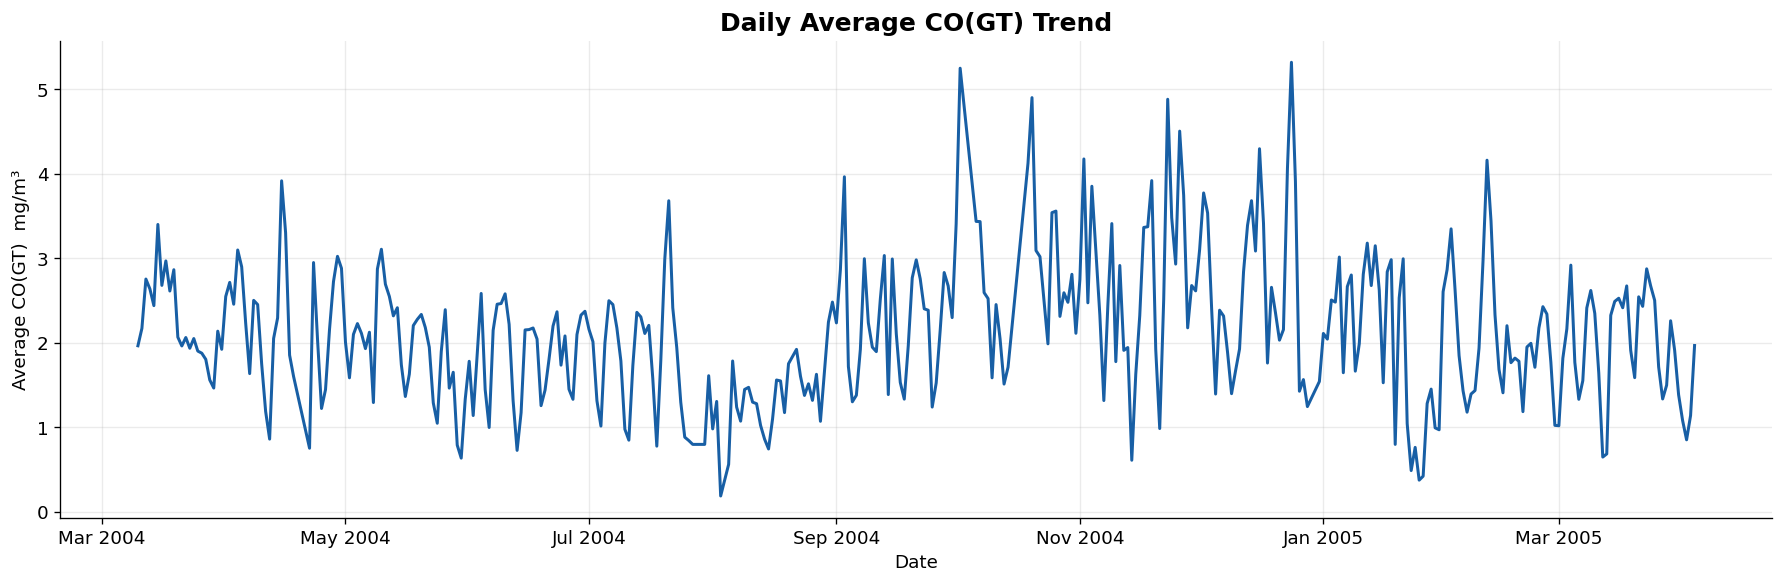

In [12]:
daily_co = df['CO(GT)'].resample('D').mean()

plt.figure(figsize=(15, 5))
plt.plot(daily_co.index, daily_co.values, linewidth=1.8, color='#185FA5')
plt.title('Daily Average CO(GT) Trend', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average CO(GT)  mg/m³')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()


###Distribution Plot

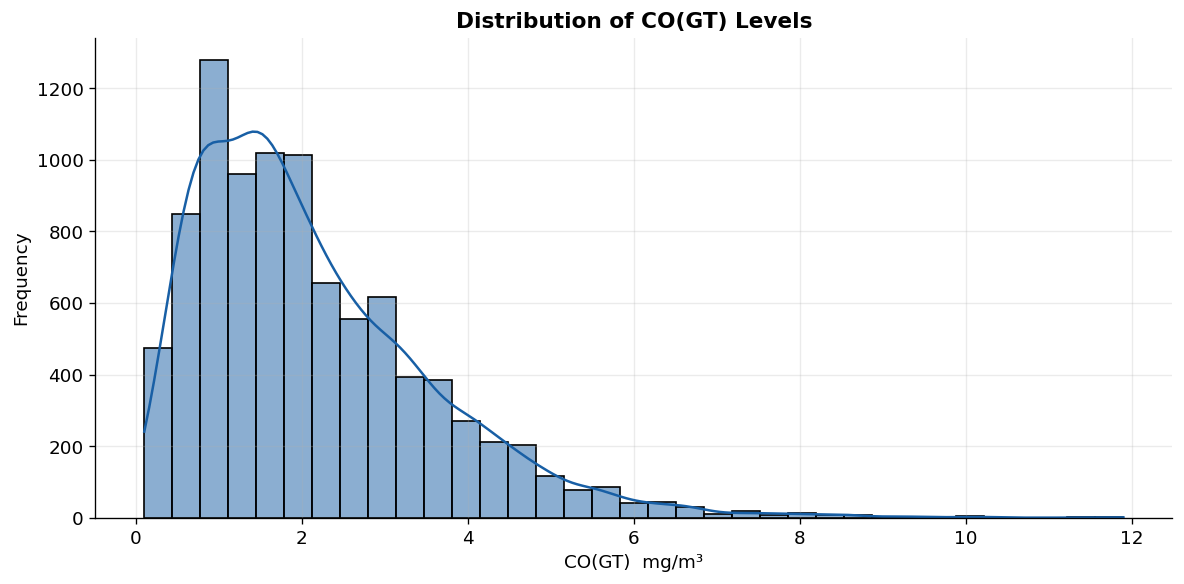

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df[target], bins=35, kde=True, color='#185FA5')
plt.title('Distribution of CO(GT) Levels', fontsize=13, fontweight='bold')
plt.xlabel('CO(GT)  mg/m³')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### Box Plot (Outlier Detection)

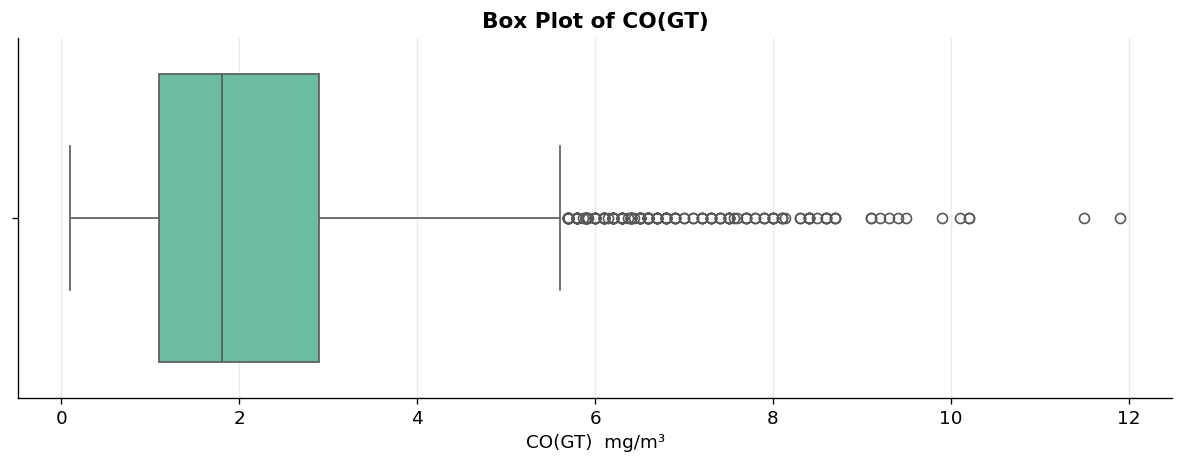

In [14]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[target], color='#5DCAA5')
plt.title('Box Plot of CO(GT)', fontsize=13, fontweight='bold')
plt.xlabel('CO(GT)  mg/m³')
plt.tight_layout()
plt.show()


###Correlation Heatmap

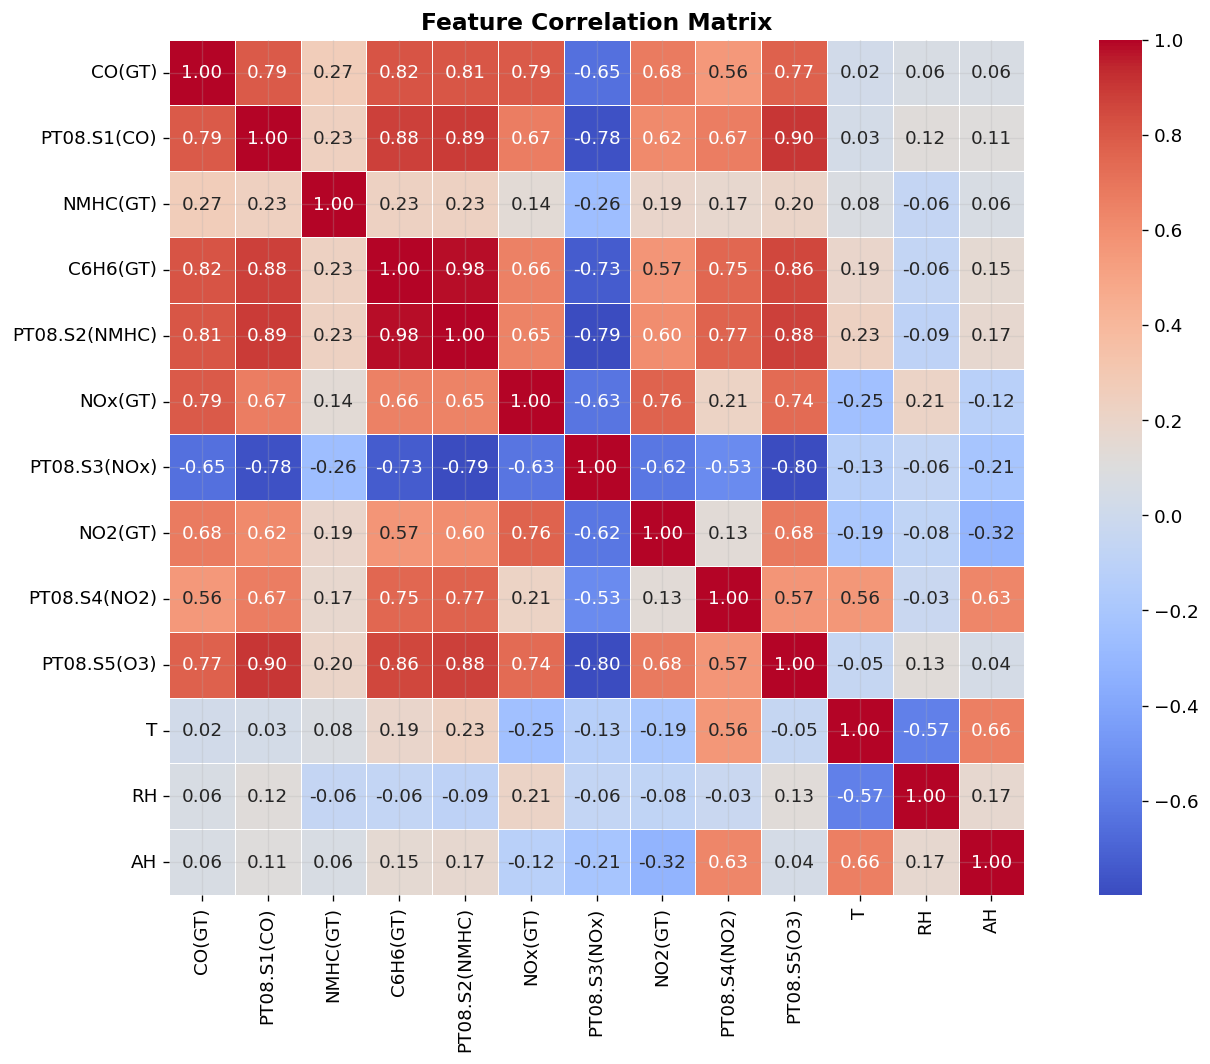

In [15]:
plt.figure(figsize=(13, 9))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    square=True
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


###STL Decomposition (Trend · Seasonal · Residual)

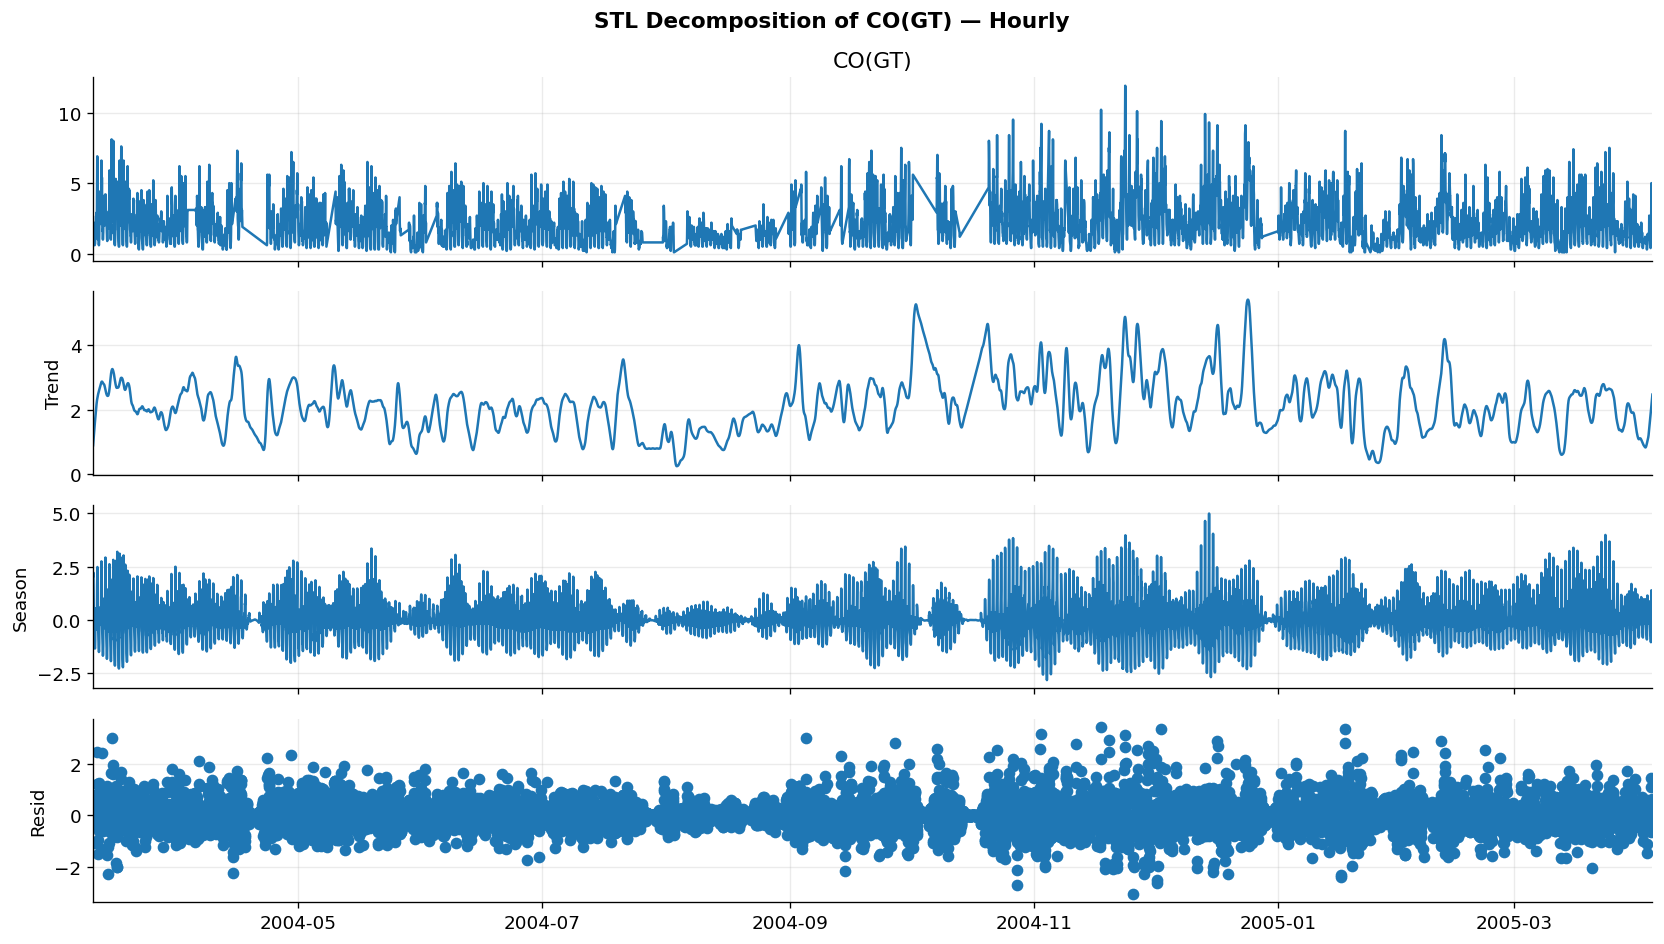

In [16]:
# STL requires a complete, evenly-spaced series — use hourly df
stl = STL(df[target], period=24)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(14, 8)
fig.suptitle('STL Decomposition of CO(GT) — Hourly', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


###Rolling Mean & Standard Deviation

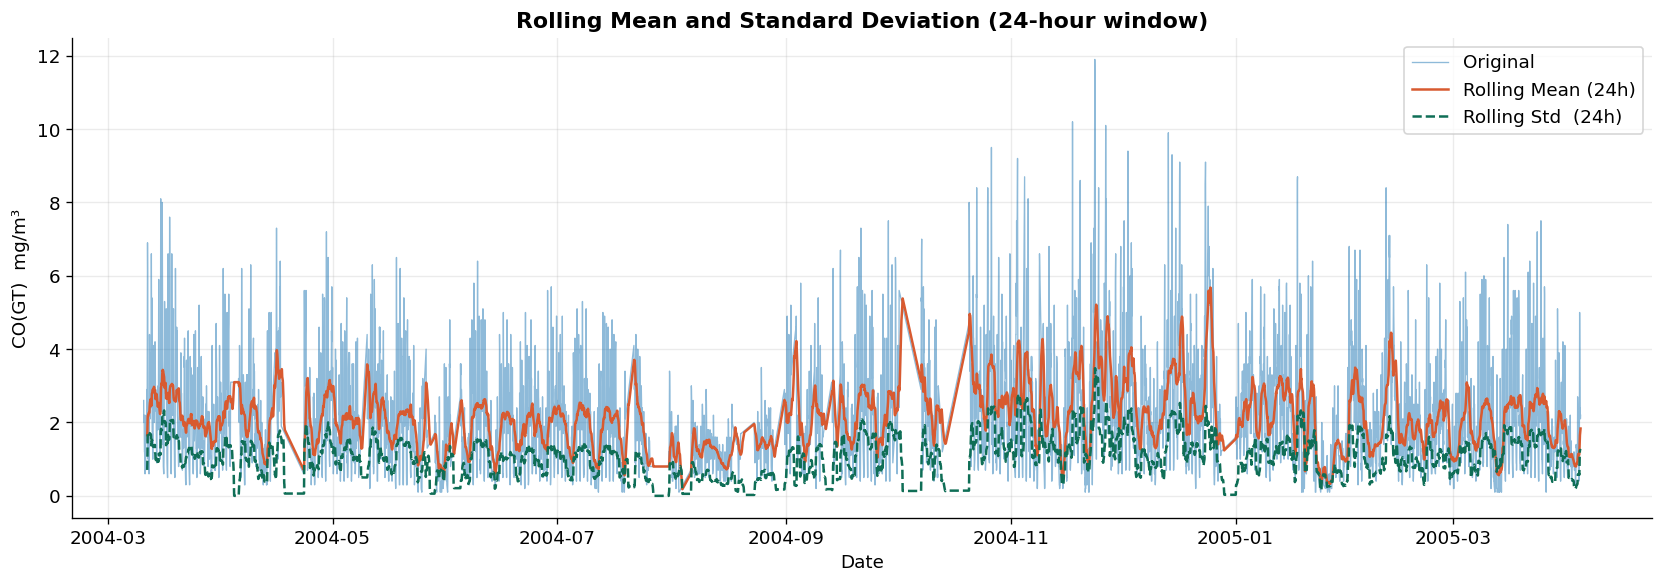

In [17]:
rolling_mean = df[target].rolling(24).mean()
rolling_std  = df[target].rolling(24).std()

plt.figure(figsize=(14, 5))
plt.plot(df[target],   label='Original',      alpha=0.5, lw=0.8)
plt.plot(rolling_mean, label='Rolling Mean (24h)',  lw=1.5, color='#D85A30')
plt.plot(rolling_std,  label='Rolling Std  (24h)', lw=1.5, color='#0F6E56', linestyle='--')
plt.legend()
plt.title('Rolling Mean and Standard Deviation (24-hour window)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('CO(GT)  mg/m³')
plt.tight_layout()
plt.show()


##Feature Engineering

###Time-Based Features

In [18]:
df['hour']      = df.index.hour
df['day']       = df.index.day
df['month']     = df.index.month
df['dayofweek'] = df.index.dayofweek

print('Time Features Created')


Time Features Created


###Lag & Rolling Features

In [19]:
df['lag_1']          = df['CO(GT)'].shift(1)
df['lag_24']         = df['CO(GT)'].shift(24)
df['rolling_mean_24']= df['CO(GT)'].rolling(24).mean()
df['rolling_std_24'] = df['CO(GT)'].rolling(24).std()

df.dropna(inplace=True)

print('Feature Engineering Complete')
print(df.shape)


Feature Engineering Complete
(9333, 21)


###Define Features & Target

In [20]:
target = 'CO(GT)'

X = df.drop(columns=[target])
y = df[target]

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (9333, 20)
y shape: (9333,)


###Time-Series Train / Test Split (80 / 20)

In [21]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (7466, 20)
X_test : (1867, 20)


## XGBoost Hyperparameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_xgb.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


##XGBoost Model

###Train XGBoost

In [23]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


###XGBoost Metrics

In [24]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_r2   = r2_score(y_test, xgb_pred)

print('RMSE:', round(xgb_rmse, 4))
print('MAE :', round(xgb_mae,  4))
print('R²  :', round(xgb_r2,   4))


RMSE: 0.4629
MAE : 0.3073
R²  : 0.8879


###XGBoost Prediction Plot

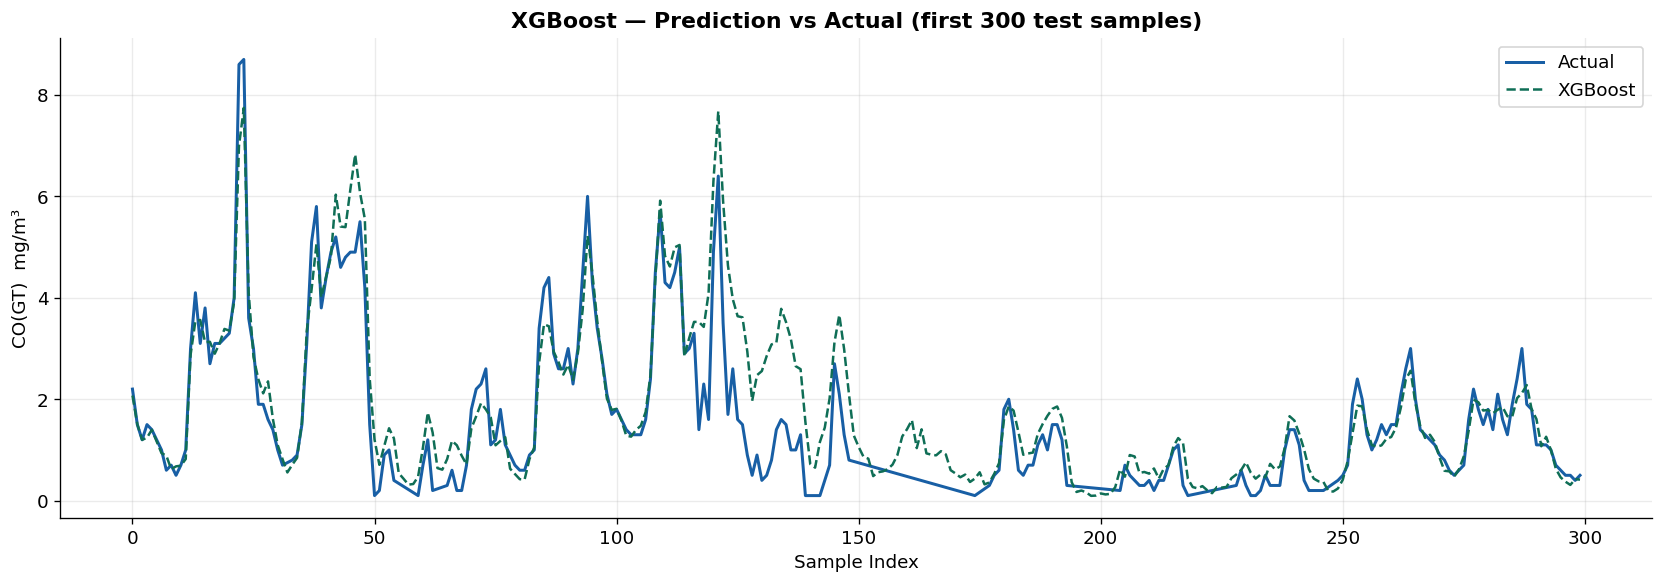

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:300],  label='Actual',   color='#185FA5', lw=1.8)
plt.plot(xgb_pred[:300],       label='XGBoost',  color='#0F6E56', lw=1.5, linestyle='--')
plt.title('XGBoost — Prediction vs Actual (first 300 test samples)', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('CO(GT)  mg/m³')
plt.legend()
plt.tight_layout()
plt.show()


###XGBoost Feature Importance

<Figure size 1200x840 with 0 Axes>

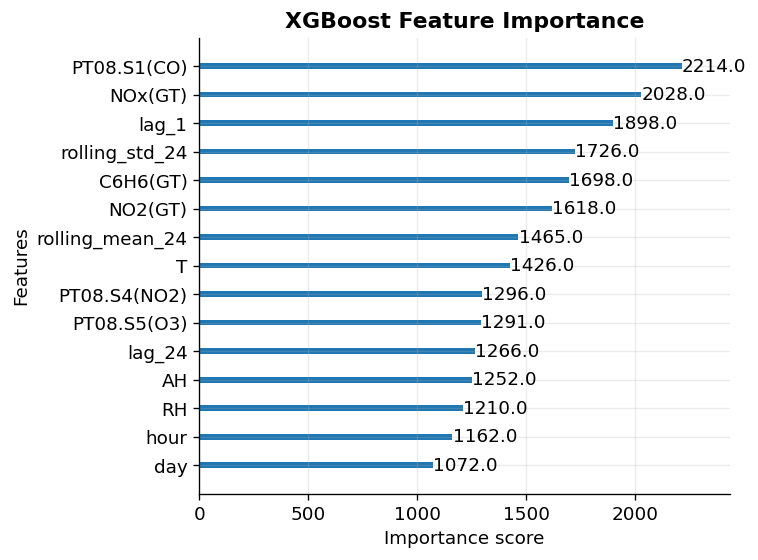

In [26]:
import matplotlib.pyplot as plt
import xgboost as xgb

plt.figure(figsize=(10,7))

xgb.plot_importance(
    xgb_model,
    max_num_features=15
)

plt.title("XGBoost Feature Importance", fontweight='bold')
plt.tight_layout()
plt.show()

##Random Forest Model

Random Forest is an ensemble of decision trees trained with bootstrap sampling and random feature subsets. It handles non-linear relationships, is robust to outliers, and provides built-in feature importance — making it a strong baseline alongside XGBoost.

## Random Forest Hyperparameter Tuning

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


###Train Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Random Forest Trained')
print('Estimators:', rf_model.n_estimators)


Random Forest Trained
Estimators: 300


###Evaluation Metrics

In [29]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print('RMSE:', round(rf_rmse, 4))
print('MAE :', round(rf_mae,  4))
print('R²  :', round(rf_r2,   4))


RMSE: 0.4969
MAE : 0.3336
R²  : 0.8708


### Actual vs Predicted Plot

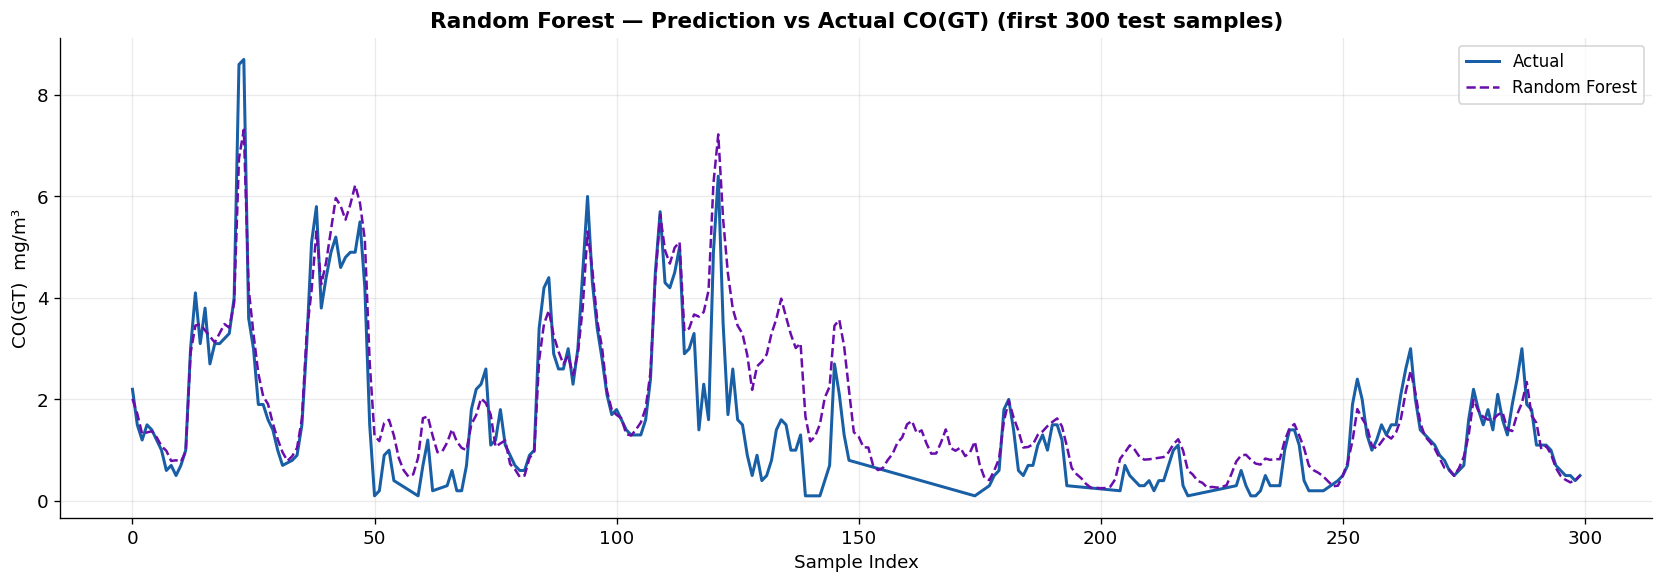

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:300],
         label='Actual',         color='#185FA5', lw=1.8)
plt.plot(rf_pred[:300],
         label='Random Forest',  color='#6A0DAD', lw=1.5, linestyle='--')
plt.title('Random Forest — Prediction vs Actual CO(GT) (first 300 test samples)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('CO(GT)  mg/m³')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


###Actual vs Predicted Scatter

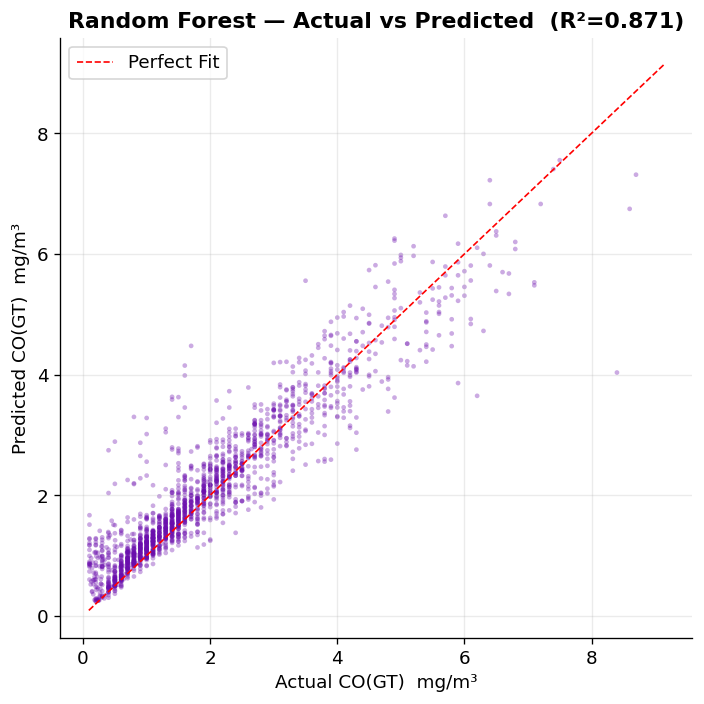

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.35, s=8, color='#6A0DAD', edgecolors='none')
lo = float(y_test.min()) * 0.9
hi = float(y_test.max()) * 1.05
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.0, label='Perfect Fit')
plt.xlabel('Actual CO(GT)  mg/m³')
plt.ylabel('Predicted CO(GT)  mg/m³')
plt.title(f'Random Forest — Actual vs Predicted  (R²={round(rf_r2, 3)})',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


###Residual Analysis

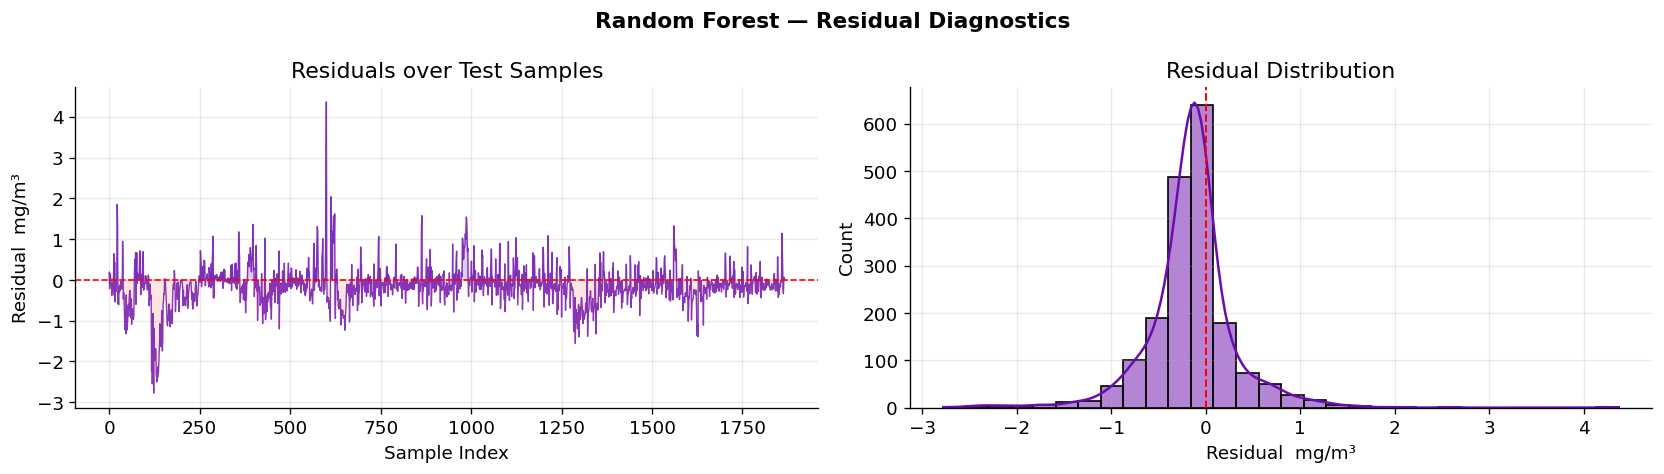

In [32]:
rf_residuals = y_test.values - rf_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Random Forest — Residual Diagnostics', fontsize=13, fontweight='bold')

axes[0].plot(rf_residuals, color='#6A0DAD', lw=0.8, alpha=0.8)
axes[0].axhline(0, color='red', lw=1.0, linestyle='--')
axes[0].fill_between(range(len(rf_residuals)), rf_residuals, 0,
                     where=rf_residuals > 0, alpha=0.2, color='#6A0DAD')
axes[0].fill_between(range(len(rf_residuals)), rf_residuals, 0,
                     where=rf_residuals < 0, alpha=0.2, color='salmon')
axes[0].set_title('Residuals over Test Samples')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Residual  mg/m³')

sns.histplot(rf_residuals, kde=True, bins=30, ax=axes[1], color='#6A0DAD')
axes[1].axvline(0, color='red', lw=1.2, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual  mg/m³')

plt.tight_layout()
plt.show()


###Feature Importance

        Feature  Importance
          lag_1    0.244296
  PT08.S2(NMHC)    0.132958
       C6H6(GT)    0.121536
        NOx(GT)    0.088778
    PT08.S1(CO)    0.088280
    PT08.S5(O3)    0.076047
        NO2(GT)    0.067757
   PT08.S3(NOx)    0.044742
rolling_mean_24    0.026476
 rolling_std_24    0.021431


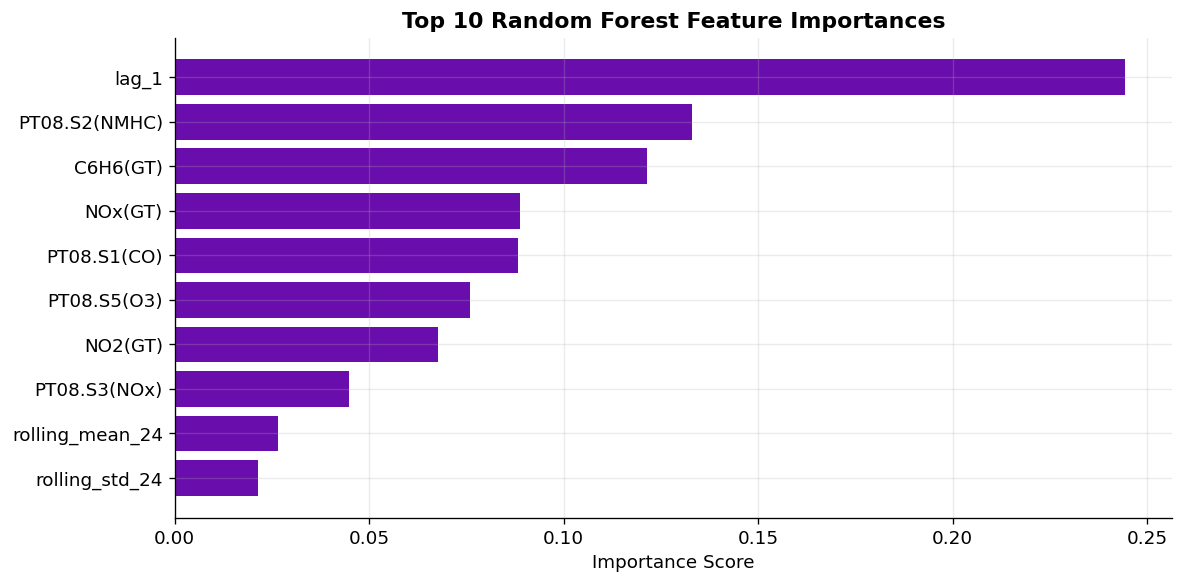

In [33]:
rf_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_importance.head(10).to_string(index=False))

top10_rf = rf_importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10_rf['Feature'][::-1], top10_rf['Importance'][::-1], color='#6A0DAD')
plt.title('Top 10 Random Forest Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


###Random Forest Results Table

In [34]:
rf_results = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²'],
    'Value' : [round(rf_rmse, 4), round(rf_mae, 4), round(rf_r2, 4)]
})

print(rf_results.to_string(index=False))


Metric  Value
  RMSE 0.4969
   MAE 0.3336
    R² 0.8708


##LSTM Deep Learning Model

###Scale Data

In [35]:
# DATA SCALING — LSTM requires [0,1] normalised input
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['CO(GT)']])

print('Scaled data shape:', scaled_data.shape)


Scaled data shape: (9333, 1)


###Create Sequences (24-Hour Look-Back Window)

In [36]:
def create_sequences(data, steps=24):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled_data, 24)

print('X_lstm shape:', X_lstm.shape)
print('y_lstm shape:', y_lstm.shape)


X_lstm shape: (9309, 24, 1)
y_lstm shape: (9309, 1)


###Train / Test Split

In [37]:
split_lstm = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_lstm]
X_test_lstm  = X_lstm[split_lstm:]
y_train_lstm = y_lstm[:split_lstm]
y_test_lstm  = y_lstm[split_lstm:]

print('X_train_lstm:', X_train_lstm.shape)
print('X_test_lstm :', X_test_lstm.shape)


X_train_lstm: (7447, 24, 1)
X_test_lstm : (1862, 24, 1)


###Build LSTM Model

In [38]:
# LSTM ARCHITECTURE
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(24, 1)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

###Compile

In [39]:
model_lstm.compile(optimizer='adam', loss='mse')
print('Model Compiled Successfully')


Model Compiled Successfully


###Train LSTM

In [40]:
from tensorflow.keras.optimizers import Adam

# Compile LSTM Model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model
history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0102 - mae: 0.0743 - val_loss: 0.0059 - val_mae: 0.0553
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 0.0058 - mae: 0.0536 - val_loss: 0.0037 - val_mae: 0.0436
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.0039 - mae: 0.0436 - val_loss: 0.0034 - val_mae: 0.0400
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0035 - mae: 0.0403 - val_loss: 0.0031 - val_mae: 0.0381
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 0.0035 - mae: 0.0400 - val_loss: 0.0032 - val_mae: 0.0429
Epoch 6/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0033 - mae: 0.0391 - val_loss: 0.0030 - val_mae: 0.0385
Epoch 7/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - loss: 0.0032 - mae: 0.0387 - val_loss: 0.0030 - val_mae: 0.0392
Epoch 8/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0031 - mae: 0.0379 - val_loss: 0.0029 - val_mae: 0.0373
Epoch 9/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 

###Training Loss Curve

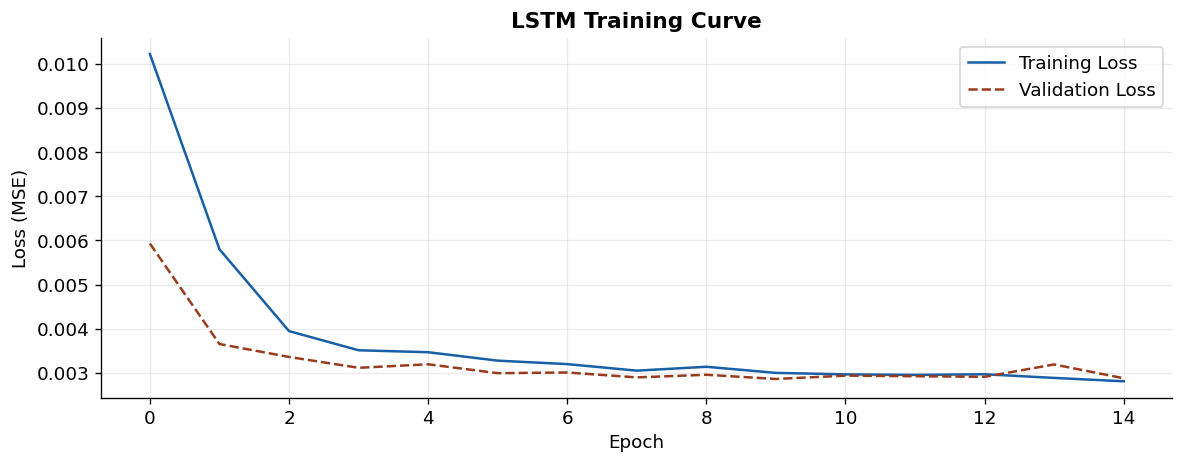

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss',   color='#185FA5', lw=1.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#993C1D', lw=1.5, linestyle='--')
plt.title('LSTM Training Curve', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()


###Predictions & Inverse Transform

In [42]:
lstm_pred = model_lstm.predict(X_test_lstm)

lstm_pred           = scaler.inverse_transform(lstm_pred.reshape(-1, 1))
y_test_lstm_actual  = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

print('Prediction shape:', lstm_pred.shape)
print('Actual shape    :', y_test_lstm_actual.shape)
print('Pred  range     :', round(float(lstm_pred.min()), 3), '->', round(float(lstm_pred.max()), 3))
print('Actual range    :', round(float(y_test_lstm_actual.min()), 3), '->', round(float(y_test_lstm_actual.max()), 3))


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Prediction shape: (1862, 1)
Actual shape    : (1862, 1)
Pred  range     : 0.045 -> 7.863
Actual range    : 0.1 -> 8.7


###LSTM Metrics

In [43]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_actual.flatten(), lstm_pred.flatten()))
lstm_mae  = mean_absolute_error(y_test_lstm_actual.flatten(), lstm_pred.flatten())
lstm_r2   = r2_score(y_test_lstm_actual.flatten(), lstm_pred.flatten())

print('RMSE:', round(lstm_rmse, 4))
print('MAE :', round(lstm_mae,  4))
print('R²  :', round(lstm_r2,   4))


RMSE: 0.6335
MAE : 0.4517
R²  : 0.7905


###LSTM Prediction Plot

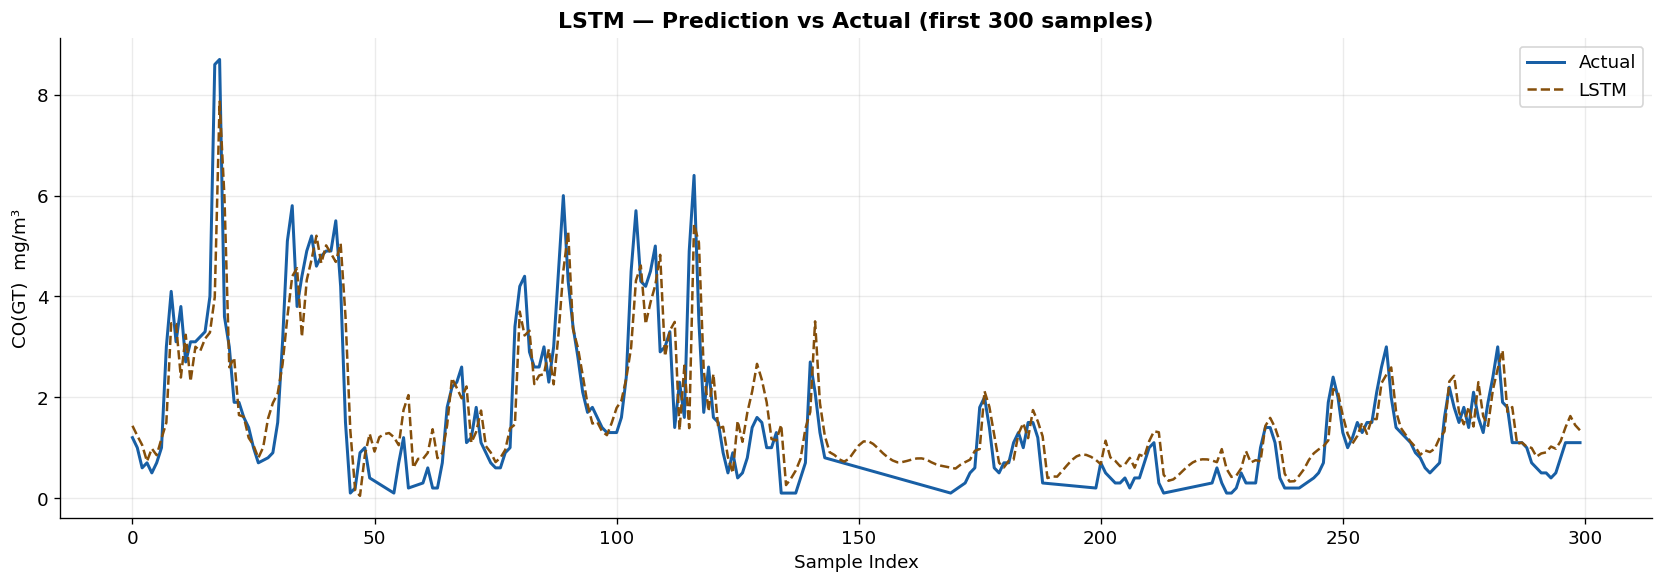

In [44]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_lstm_actual[:300], label='Actual', color='#185FA5', lw=1.8)
plt.plot(lstm_pred[:300],          label='LSTM',   color='#854F0B', lw=1.5, linestyle='--')
plt.title('LSTM — Prediction vs Actual (first 300 samples)', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('CO(GT)  mg/m³')
plt.legend()
plt.tight_layout()
plt.show()


###Error Distribution

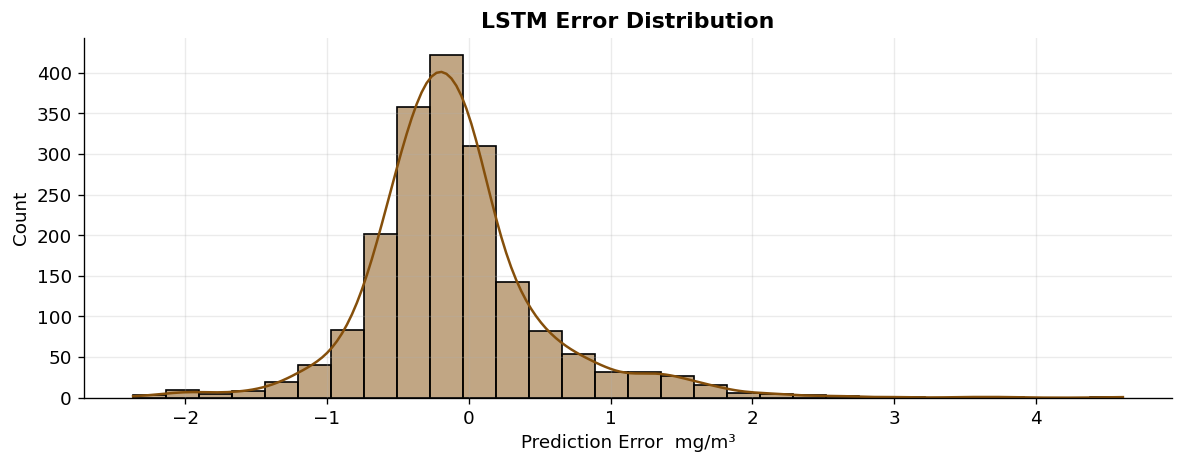

In [45]:
errors = y_test_lstm_actual.flatten() - lstm_pred.flatten()

plt.figure(figsize=(10, 4))
sns.histplot(errors, kde=True, bins=30, color='#854F0B')
plt.title('LSTM Error Distribution', fontweight='bold')
plt.xlabel('Prediction Error  mg/m³')
plt.tight_layout()
plt.show()


###Residual Scatter

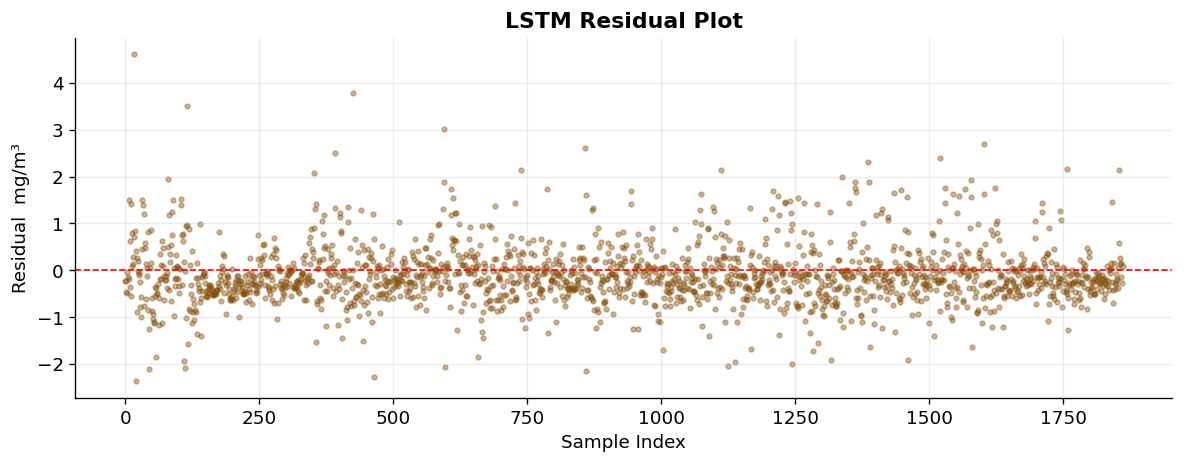

In [46]:
plt.figure(figsize=(10, 4))
plt.scatter(range(len(errors)), errors, alpha=0.4, s=8, color='#854F0B')
plt.axhline(0, color='red', lw=1.0, linestyle='--')
plt.title('LSTM Residual Plot', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Residual  mg/m³')
plt.tight_layout()
plt.show()


###Actual vs Predicted Scatter

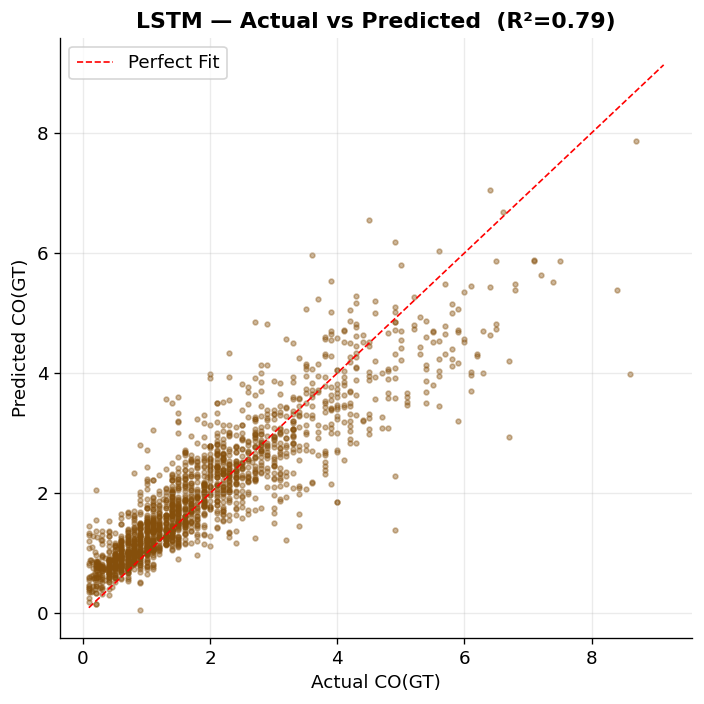

In [47]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_lstm_actual, lstm_pred, alpha=0.4, s=8, color='#854F0B')
lo = float(y_test_lstm_actual.min()) * 0.9
hi = float(y_test_lstm_actual.max()) * 1.05
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.0, label='Perfect Fit')
plt.xlabel('Actual CO(GT)')
plt.ylabel('Predicted CO(GT)')
plt.title(f'LSTM — Actual vs Predicted  (R²={round(lstm_r2,3)})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


##Final Model Comparison

###Results Table

In [48]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'LSTM'],
    'RMSE' : [xgb_rmse, rf_rmse, lstm_rmse],
    'MAE'  : [xgb_mae, rf_mae, lstm_mae],
    'R2'   : [xgb_r2, rf_r2, lstm_r2]
})

results = results.round(4)

print(results.to_string(index=False))

        Model   RMSE    MAE     R2
      XGBoost 0.4629 0.3073 0.8879
Random Forest 0.4969 0.3336 0.8708
         LSTM 0.6335 0.4517 0.7905


In [49]:
results.to_csv('Model_Results.csv', index=False)
print('Results Saved → Model_Results.csv')


Results Saved → Model_Results.csv


###RMSE / MAE / R² Comparison Charts

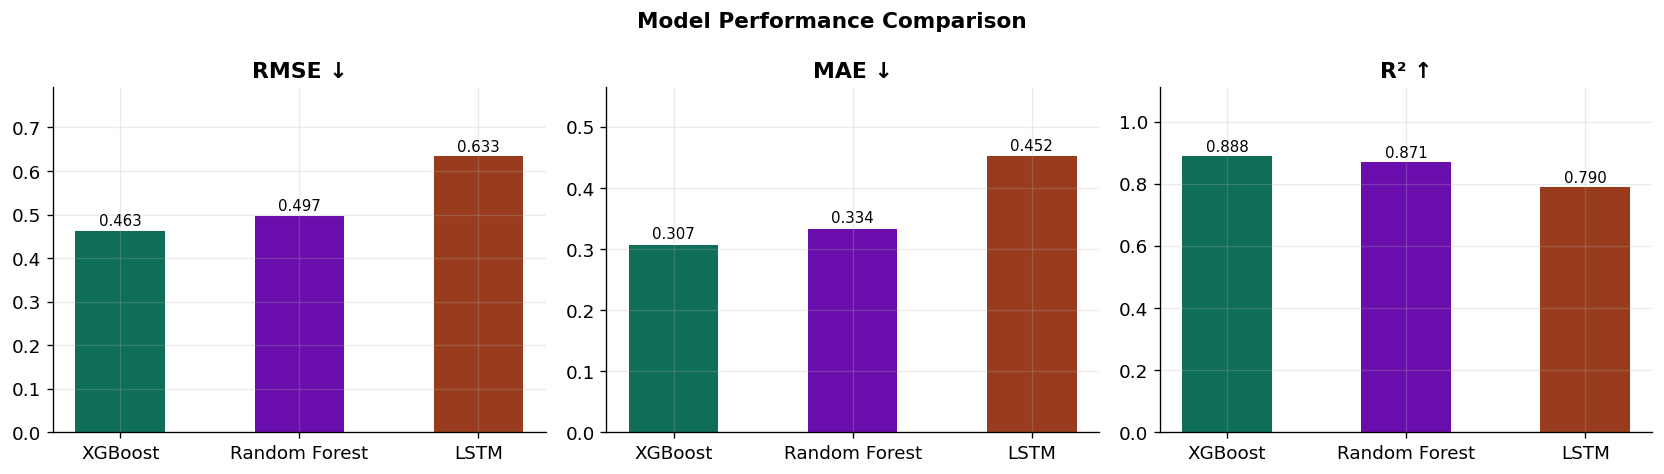

In [50]:
bar_colors = ['#0F6E56', '#6A0DAD', '#993C1D', '#854F0B']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

for ax, metric, title in zip(axes, ['RMSE','MAE','R2'], ['RMSE ↓','MAE ↓','R² ↑']):
    bars = ax.bar(results['Model'], results[metric], color=bar_colors, edgecolor='none', width=0.5)
    for bar, v in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, results[metric].max() * 1.25)

plt.tight_layout()
plt.show()


###All-Model Overlay on Test Set

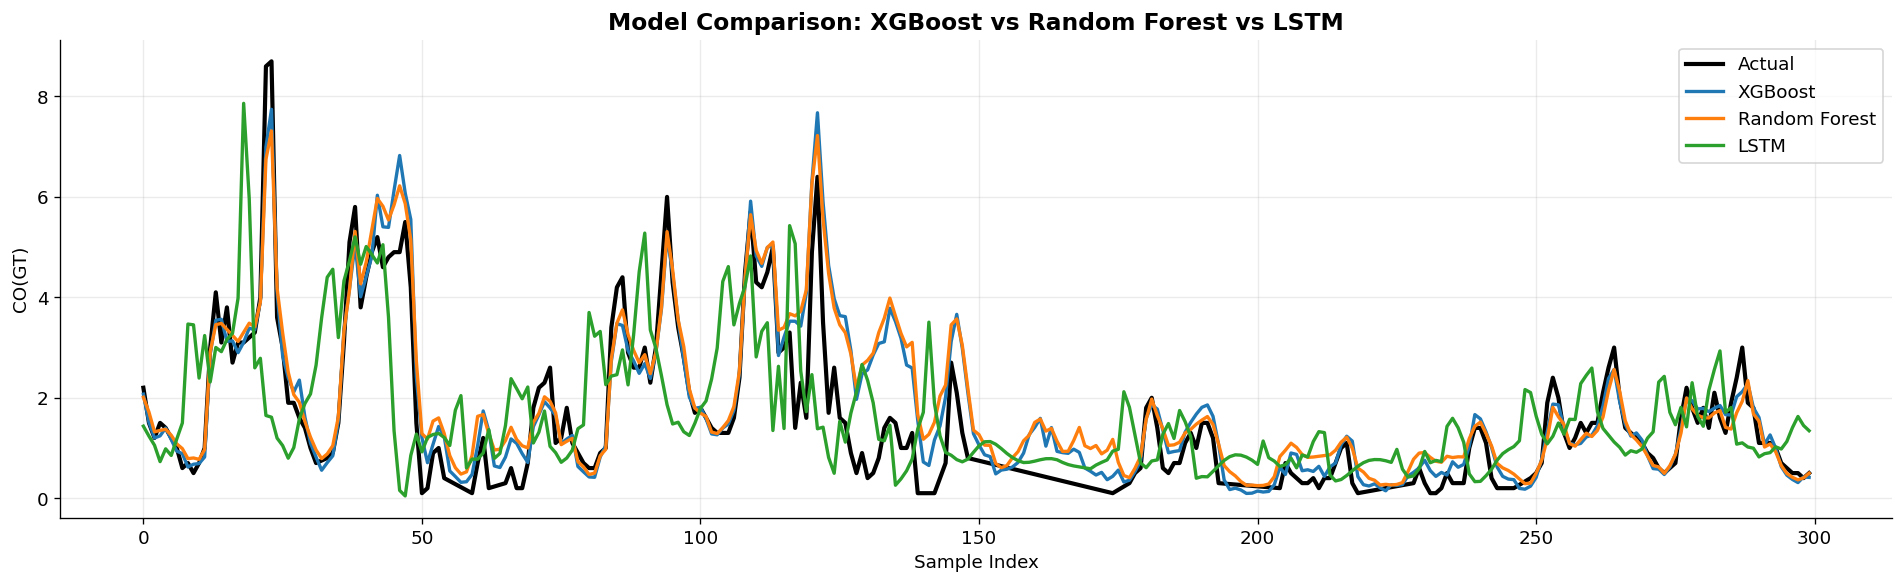

In [51]:
zoom = 300

plt.figure(figsize=(16,5))

plt.plot(
    y_test.values[:zoom],
    label='Actual',
    color='black',
    linewidth=2.5
)

plt.plot(
    xgb_pred[:zoom],
    label='XGBoost',
    linewidth=2
)

plt.plot(
    rf_pred[:zoom],
    label='Random Forest',
    linewidth=2
)

plt.plot(
    lstm_pred.flatten()[:zoom],
    label='LSTM',
    linewidth=2
)

plt.title(
    'Model Comparison: XGBoost vs Random Forest vs LSTM',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Sample Index')
plt.ylabel('CO(GT)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

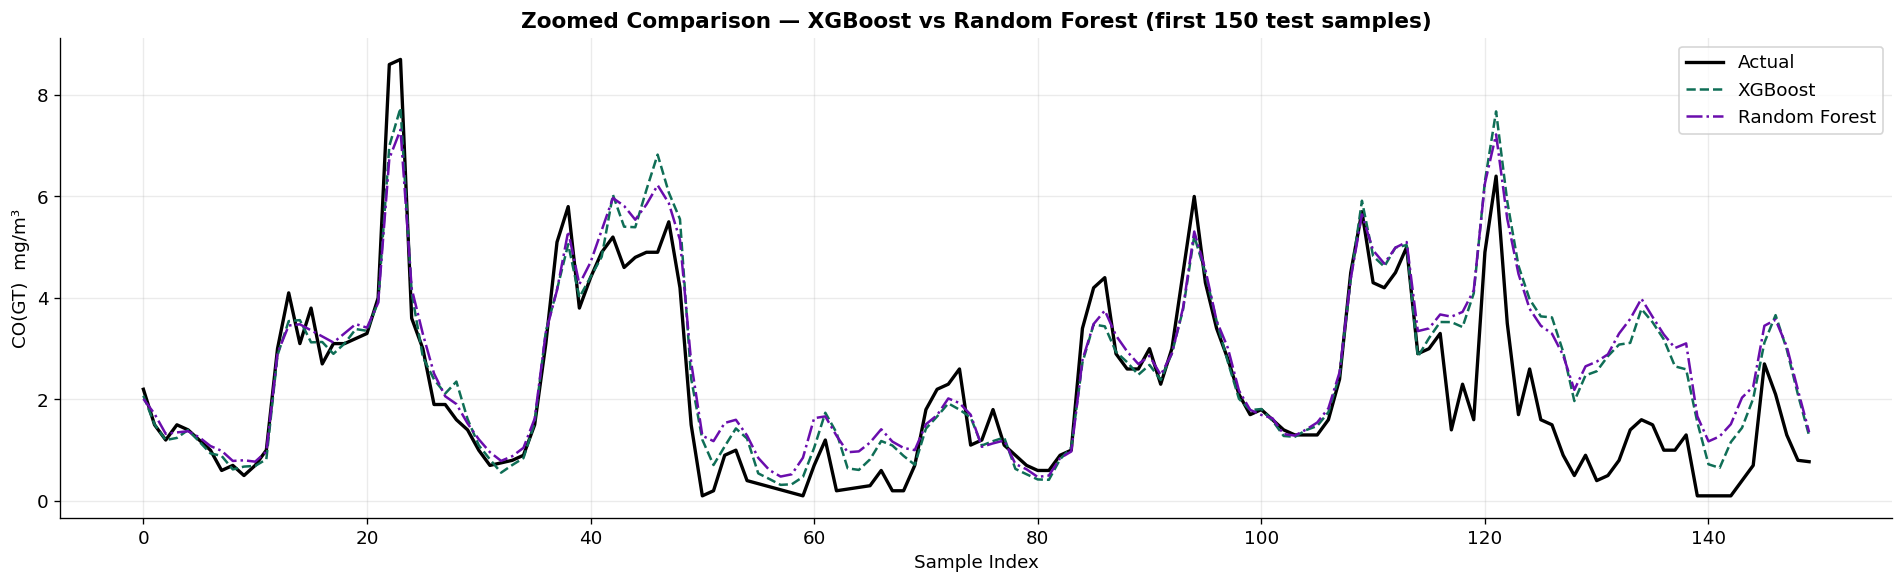

In [52]:
zoom2 = 150

plt.figure(figsize=(16, 5))
plt.plot(y_test.values[:zoom2],        label='Actual',        color='black',   lw=2.0)
plt.plot(xgb_pred[:zoom2],             label='XGBoost',       color='#0F6E56', lw=1.5, linestyle='--')
plt.plot(rf_pred[:zoom2],              label='Random Forest', color='#6A0DAD', lw=1.5, linestyle='-.')
plt.title('Zoomed Comparison — XGBoost vs Random Forest (first 150 test samples)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('CO(GT)  mg/m³')
plt.legend()
plt.tight_layout()
plt.show()


##SHAP Explainable AI

###Generate SHAP Values

In [53]:
explainer   = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

print('SHAP Values Generated')


SHAP Values Generated


###SHAP Summary Plot (Beeswarm)

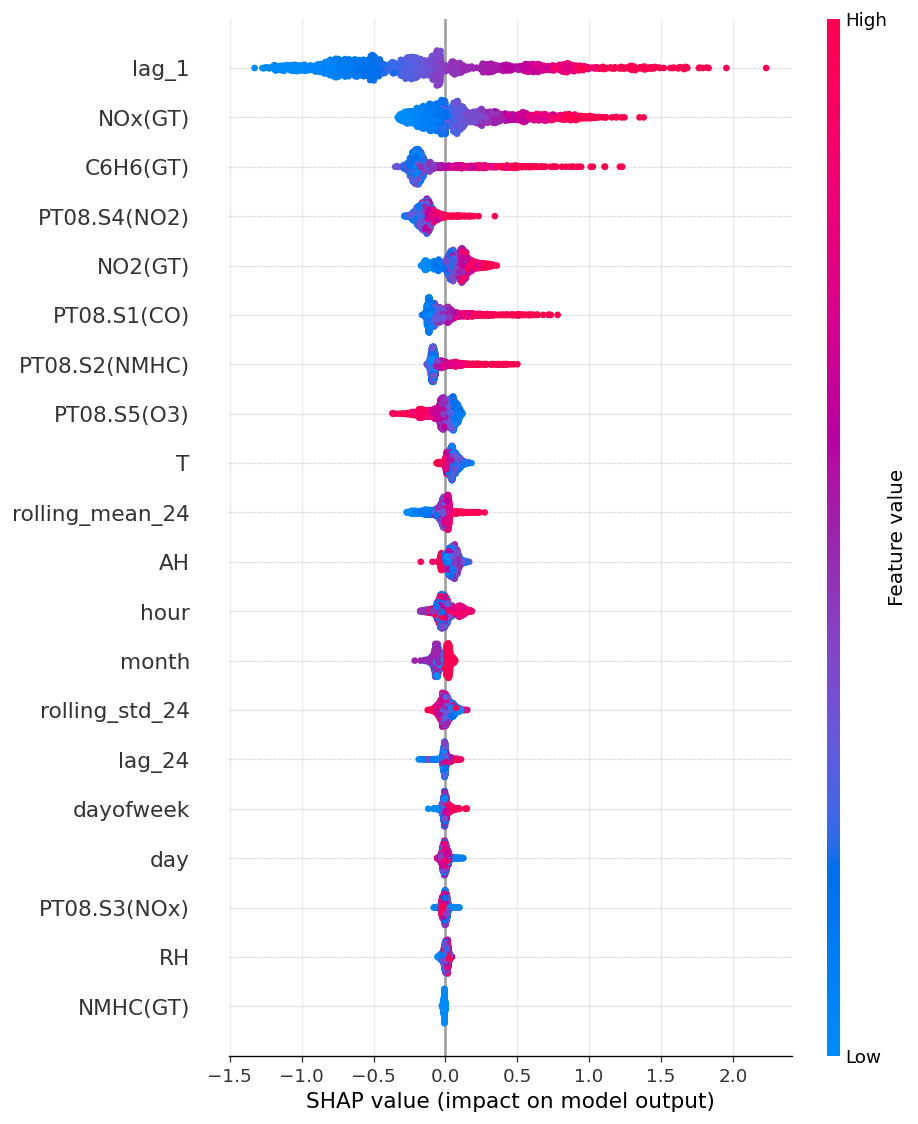

In [54]:
shap.summary_plot(shap_values, X_test)


###SHAP Bar Plot (Mean Importance)

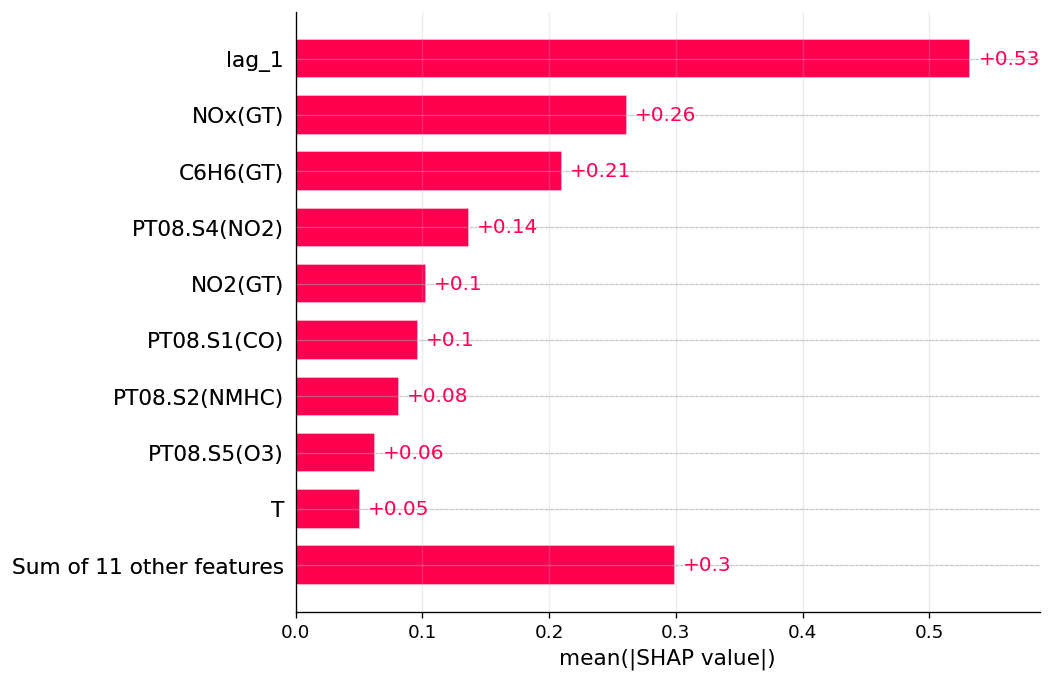

In [55]:
shap.plots.bar(shap_values)


###Top 10 Feature Importances

In [56]:
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(10).to_string(index=False))


        Feature  Importance
          lag_1    0.451647
       C6H6(GT)    0.162073
  PT08.S2(NMHC)    0.128823
        NOx(GT)    0.060495
    PT08.S1(CO)    0.036904
        NO2(GT)    0.029651
 rolling_std_24    0.018189
rolling_mean_24    0.015098
   PT08.S4(NO2)    0.012450
    PT08.S5(O3)    0.011945


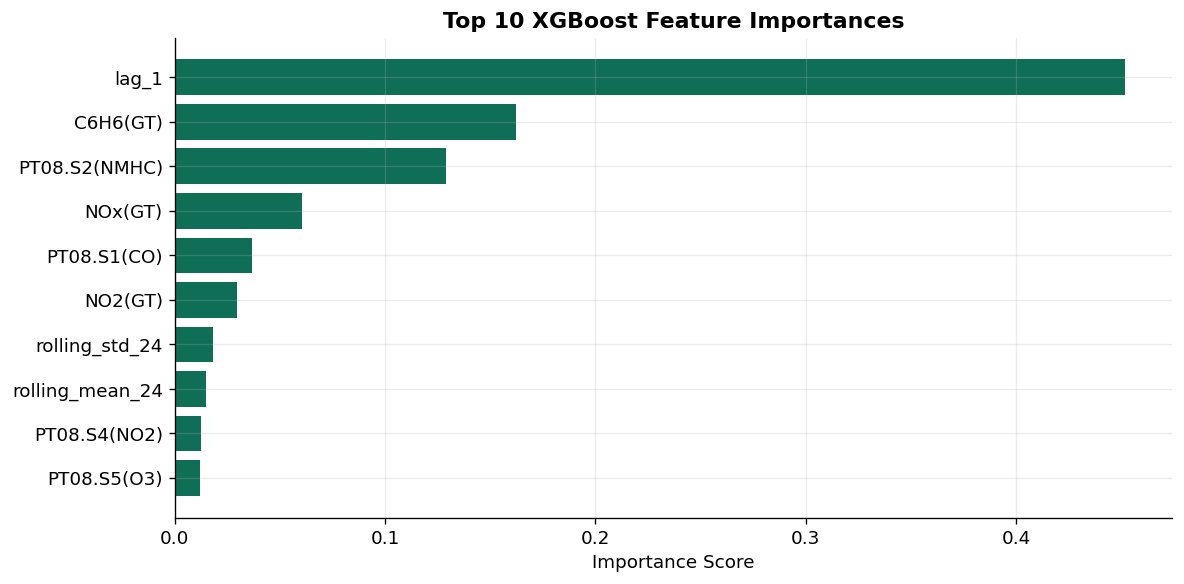

In [57]:
top10 = importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='#0F6E56')
plt.title('Top 10 XGBoost Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


##Project Summary

In [58]:
best_model = results.loc[results['RMSE'].idxmin()]

print("="*50)
print(" AQI PREDICTION PROJECT - COMPLETE ")
print("="*50)

print("\nModels Evaluated :")
print("- XGBoost")
print("- Random Forest")
print("- LSTM")

print("Explainable AI : SHAP (XGBoost)")

print(f"\nBest Model : {best_model['Model']}")
print(f"Best RMSE  : {best_model['RMSE']:.4f}")
print(f"Best MAE   : {best_model['MAE']:.4f}")
print(f"Best R²    : {best_model['R2']:.4f}")

print("\nAll plots and results generated successfully.")

 AQI PREDICTION PROJECT - COMPLETE 

Models Evaluated :
- XGBoost
- Random Forest
- LSTM
Explainable AI : SHAP (XGBoost)

Best Model : XGBoost
Best RMSE  : 0.4629
Best MAE   : 0.3073
Best R²    : 0.8879

All plots and results generated successfully.
